# HSI Spatial Calibration


## Import Libraries


In [ ]:
import os
import sys
import math
import numpy as np
import pandas as pd
import spectral
from IPython.core import ultratb
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, Point
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# Enable support for ENVI header files with non-lowercase parameter names
spectral.settings.envi_support_nonlowercase_params = True

## Read HSI


In [ ]:
def read_hsi(hdr_file):
    """
    Read a hyperspectral image and return the image and its wavelengths
    """
    image = spectral.open_image(hdr_file).load()
    wavelengths = [float(w) for w in image.metadata["Wavelength"]]

    return image, wavelengths

## Bands Visualization


In [ ]:
def plot_bands(image, wavelengths, n=1):
    """
    Plots each band (or every n bands) as a grayscale image.
    """
    # Get number of bands
    num_bands = image.shape[-1]

    # Select bands based on step size
    bands_to_plot = list(range(0, num_bands, n))

    # Determine plot grid
    num_plots = len(bands_to_plot)
    cols = min(5, num_plots)  # Set a max of 5 columns
    rows = (num_plots // cols) + (num_plots % cols > 0)

    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = np.atleast_2d(axes)  # Ensure 2D array for indexing

    # Plot each selected band
    for idx, band in enumerate(bands_to_plot):
        row, col = divmod(idx, cols)
        ax = axes[row, col]
        ax.imshow(image[:, :, band], cmap="gray")
        ax.set_title(f"Band {band}: {wavelengths[band]} nm")
        ax.axis("off")

    # Remove empty subplots if any
    for idx in range(num_plots, rows * cols):
        row, col = divmod(idx, cols)
        fig.delaxes(axes[row, col])

    plt.tight_layout()
    plt.show()

## Average Bands


In [ ]:
def average_bands(image, start_band, end_band):
    """
    Reads a hyperspectral image and computes the average grayscale image across the specified bands.
    """
    # Validate band indices
    num_bands = image.shape[-1]
    start_band = max(0, min(start_band, num_bands - 1))
    end_band = max(0, min(end_band, num_bands - 1))

    if start_band > end_band:
        raise ValueError("start_band must be less than or equal to end_band.")

    # Compute the average grayscale image across the selected bands
    avg_image = np.mean(image[:, :, start_band : end_band + 1], axis=2)

    # Display the averaged grayscale image
    plt.imshow(avg_image, cmap="gray")
    plt.title(f"Average Image (Bands {start_band} to {end_band})")
    plt.axis("off")
    plt.show()

    return avg_image

## Pattern Extraction


In [ ]:
def pattern_extraction(xml_file, image):
    """
    Extracts the ROI polygon from an averaged grayscale image based on the input XML file.
    """
    tree = ET.parse(xml_file)
    root = tree.getroot()

    # Extract ROI name
    region = root.find(".//Region")
    roi_name = region.get("name") if region is not None else "Unknown ROI"

    # Extract coordinates from XML
    coords_text = root.find(".//Coordinates").text.strip()

    # Convert to a list of floats
    coord_values = list(map(float, coords_text.split()))

    # Convert flat list into pairs (x, y)
    coords = [
        (int(round(coord_values[i])), int(round(coord_values[i + 1])))
        for i in range(0, len(coord_values), 2)
    ]

    # Convert coordinates to integer pixel indices
    roi_polygon = Polygon(coords)

    # Create a mask
    mask = np.zeros_like(image, dtype=bool)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            if roi_polygon.contains(Point(x, y)):
                mask[y, x] = True

    # Crop the ROI using the bounding box
    min_x, min_y, max_x, max_y = map(int, roi_polygon.bounds)
    roi_cropped = image[min_y:max_y, min_x:max_x]

    # Display the ROI image
    plt.imshow(roi_cropped, cmap="gray")
    plt.title(f"{roi_name}")
    plt.axis("off")
    plt.show()

    return roi_cropped

In [ ]:
def average_pattern_intensity(roi_cropped, output_csv="roi_intensity.csv"):
    """
    Calculates the mean intensity along the x-axis of the extracted ROI,
    saves the result to a CSV file, and plots intensity vs. pixel number along the y-axis.

    """
    # Compute mean intensity along x-axis
    mean_intensity = np.nanmean(roi_cropped, axis=1)
    y_pixels = np.arange(len(mean_intensity))

    # Save to CSV
    # df = pd.DataFrame({"Pixel_Y": y_pixels, "Mean_Intensity": mean_intensity})
    # df.to_csv(output_csv, index=False)
    # print(f"Saved intensity profile to {output_csv}")

    # Plot intensity profile along y-axis
    plt.figure(figsize=(8, 5))
    plt.plot(y_pixels, mean_intensity)
    plt.xlabel("Pixel Number")
    plt.ylabel("Mean Intensity")
    plt.title(f"Intensity Profile Along Y-Axis")
    plt.grid(True)
    plt.show()

    return mean_intensity

## Contrast Transfer Function (CTF)


In [ ]:
def compute_ctf(intensity_profile):
    """
    Identifies peak-valley pairs and calculates the Contrast Transfer Function (CTF).
    Labels CTF values at the first peak of each peak-valley-peak pair.
    """

    # Apply Gaussian smoothing
    smoothed_profile = gaussian_filter1d(intensity_profile, sigma=2)

    y_pixels = np.arange(len(smoothed_profile))

    # Find peaks and valleys in the smoothed profile
    peaks, _ = find_peaks(smoothed_profile, distance=10)
    valleys, _ = find_peaks(-smoothed_profile, distance=10)

    # Ensure peak-valley-peak pairs
    peak_valley_pairs = []
    valid_peaks = set()
    valid_valleys = set()

    for i in range(len(peaks) - 1):
        peak = peaks[i]
        next_peak = peaks[i + 1]

        # Find the closest valley between two peaks
        valid_valleys_indices = valleys[(valleys > peak) & (valleys < next_peak)]
        if len(valid_valleys_indices) > 0:
            valley = valid_valleys_indices[
                np.argmin(np.abs(valid_valleys_indices - peak))
            ]
            peak_valley_pairs.append((peak, valley, next_peak))
            valid_peaks.add(peak)
            valid_peaks.add(next_peak)
            valid_valleys.add(valley)

    # Calculate Contrast Transfer Function (CTF)
    ctf_values = []
    for peak, valley, next_peak in peak_valley_pairs:
        I_max = smoothed_profile[peak]
        I_min = smoothed_profile[valley]
        ctf = (I_max - I_min) / (I_max + I_min)
        ctf_values.append((peak, ctf))  # Label CTF at first peak

    # Plot the smoothed intensity and mark peaks/valleys
    plt.figure(figsize=(10, 5))
    plt.plot(y_pixels, smoothed_profile, label="Intensity", color="blue")

    # Plot only the valid peaks and valleys in the peak-valley-peak pairs
    plt.scatter(
        list(valid_peaks),
        smoothed_profile[list(valid_peaks)],
        color="red",
        label="Valid Peaks",
        marker="o",
    )
    plt.scatter(
        list(valid_valleys),
        smoothed_profile[list(valid_valleys)],
        color="green",
        label="Valid Valleys",
        marker="x",
    )

    # Annotate CTF values at the first peak of each triplet
    for peak, ctf in ctf_values:
        plt.annotate(
            f"{ctf:.2f}",
            (peak, smoothed_profile[peak]),
            textcoords="offset points",
            xytext=(-10, 5),
            ha="center",
            fontsize=10,
            color="red",
        )

    plt.xlabel("Pixel Number")
    plt.ylabel("Mean Intensity")
    plt.title("Intensity Profile with CTF")
    plt.legend()
    plt.grid(True)
    plt.show()

    return peak_valley_pairs, ctf_values

## Main


In [ ]:
# Set the .hdr file path
hdr_file = "/mnt/c/data/focus3ft_preprocessed/20250225_13-58-13/1/reflectance_1.hdr"

# Read the .hdr file
image, wavelengths = read_hsi(hdr_file)

In [ ]:
# Plot the band visualization
plot_bands(image=image, wavelengths=wavelengths)

# Average the selected bands for clearer visualization of the patterns
avg_image = average_bands(image=image, start_band=140, end_band=149)

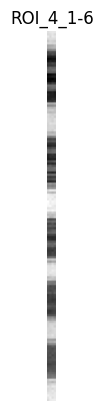

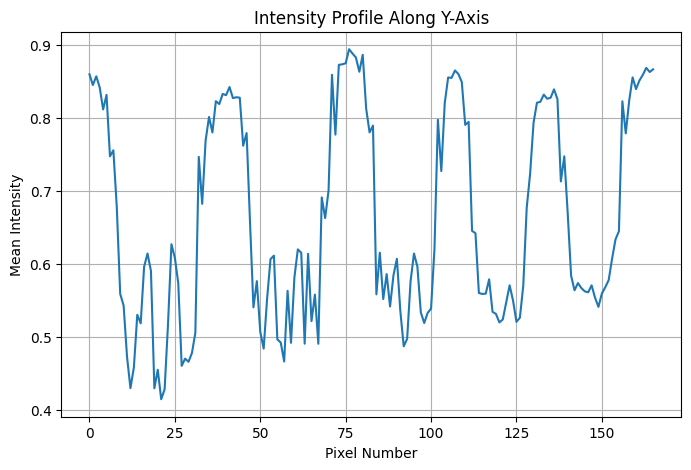

In [14]:
# Extract and analyze the resolution pattern
roi_xml_path = "/mnt/c/data/ROI_4_1-6.xml"
roi_cropped = pattern_extraction(roi_xml_path, avg_image)
mean_intensity = average_pattern_intensity(
    roi_cropped, output_csv="../data/roi_intensity.csv"
)

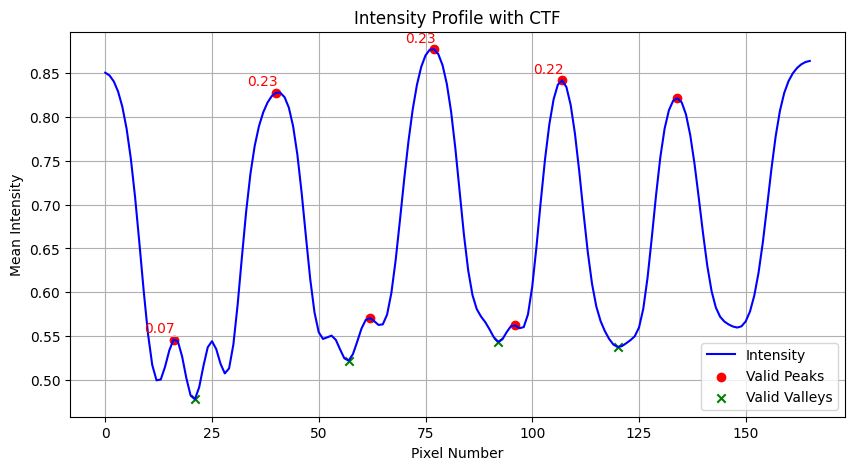

([(16, 21, 40), (40, 57, 62), (77, 92, 96), (107, 120, 134)],
 [(16, 0.066542394), (40, 0.22661093), (77, 0.23498414), (107, 0.22070529)])

In [15]:
# Determine the peaks and valleys and calculate the CTF values
compute_ctf(mean_intensity)